In [ ]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [ ]:
!pip install -q sentence-transformers
!pip install --user sentence-transformers
!pip install -U sentence-transformers
!pip install transformers
!pip install torch
!pip install datasets

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
text_df=pd.read_csv("/content/labeling_preprocess.csv")
text_df

,Unnamed: 0,text,sentiment
0,0,final got tire anxiou depress cri daili leav h...,Neutral
1,1,best friend die last year rare type bacteria k...,Negative
2,3,employ full time money tri put money minu tran...,Negative
3,4,ive ptsd year come decad decemb last year ive ...,Negative
4,6,will pay slightli higher rate interest mean ab...,Negative
...,...,...,...
561328,561328,walk around feel quit tortur spent mani hour s...,positive
561329,561329,took minut appreci tree around calm energi gav...,positive
561330,561330,move away said someth made feel violent someth...,positive
561331,561331,brief time beanbag said anna feel like beaten,positive


In [ ]:
text_df.isnull().sum()

,0
Unnamed: 0,0
text,0
sentiment,0


In [ ]:
text_df.duplicated().sum()

0

In [ ]:
text_df= text_df.reset_index(drop=True)
text_df

,Unnamed: 0,text,sentiment
0,0,final got tire anxiou depress cri daili leav h...,Neutral
1,1,best friend die last year rare type bacteria k...,Negative
2,3,employ full time money tri put money minu tran...,Negative
3,4,ive ptsd year come decad decemb last year ive ...,Negative
4,6,will pay slightli higher rate interest mean ab...,Negative
...,...,...,...
561328,561328,walk around feel quit tortur spent mani hour s...,positive
561329,561329,took minut appreci tree around calm energi gav...,positive
561330,561330,move away said someth made feel violent someth...,positive
561331,561331,brief time beanbag said anna feel like beaten,positive


In [ ]:
text_df['sentiment'].value_counts()

,count
sentiment,
positive,225690
Negative,194676
Neutral,116279
Highly positive,24688


In [ ]:
text_df = text_df.rename(columns={"sentiment":"label"})
text_df

,Unnamed: 0,text,label
0,0,final got tire anxiou depress cri daili leav h...,Neutral
1,1,best friend die last year rare type bacteria k...,Negative
2,3,employ full time money tri put money minu tran...,Negative
3,4,ive ptsd year come decad decemb last year ive ...,Negative
4,6,will pay slightli higher rate interest mean ab...,Negative
...,...,...,...
561328,561328,walk around feel quit tortur spent mani hour s...,positive
561329,561329,took minut appreci tree around calm energi gav...,positive
561330,561330,move away said someth made feel violent someth...,positive
561331,561331,brief time beanbag said anna feel like beaten,positive


In [ ]:
text_df.drop(columns=["Unnamed: 0"], inplace=True)

In [ ]:
text_df["label"] = text_df["label"].replace({
    "positive": "Positive",
    "Negative": "Negative",
    "Neutral": "Neutral",
    "Highly positive": "Highly Positive"
})
text_df['label'].value_counts()

,count
label,
Positive,225690
Negative,194676
Neutral,116279
Highly Positive,24688


In [ ]:
label_mapping = {
    "Negative": 0,
    "Positive": 1,
    "Highly Positive": 2,
    "Neutral": 3
}

text_df["label"] = text_df["label"].map(label_mapping)

In [ ]:
text_df

,text,label
0,final got tire anxiou depress cri daili leav h...,3
1,best friend die last year rare type bacteria k...,0
2,employ full time money tri put money minu tran...,0
3,ive ptsd year come decad decemb last year ive ...,0
4,will pay slightli higher rate interest mean ab...,0
...,...,...
561328,walk around feel quit tortur spent mani hour s...,1
561329,took minut appreci tree around calm energi gav...,1
561330,move away said someth made feel violent someth...,1
561331,brief time beanbag said anna feel like beaten,1


In [ ]:
from datasets import Dataset
from sklearn.model_selection import train_test_split
dataset = Dataset.from_dict(text_df)
dataset

Dataset({
    features: ['text', 'label'],
    num_rows: 561333
})

In [ ]:
dataset= dataset.train_test_split(test_size=0.2)
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 449066
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 112267
    })
})

In [ ]:
test_dataset=dataset['test']
test_dataset

Dataset({
    features: ['text', 'label'],
    num_rows: 112267
})

**RoBERTa Model**

In [ ]:
from transformers import AutoTokenizer
from transformers import RobertaTokenizer, RobertaForSequenceClassification, Trainer, TrainingArguments

model_name = "cardiffnlp/twitter-roberta-base-sentiment-latest"
text_tokenizer = RobertaTokenizer.from_pretrained(model_name)
text_model = RobertaForSequenceClassification.from_pretrained(model_name, num_labels=4,ignore_mismatched_sizes=True)

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest and are newly initialized because the shapes did not match:
- classifier.out_proj.weight: found shape torch.Size([3, 768]) in the checkpo

In [ ]:
def preprocess_text(text):
    tokenized_output = text_tokenizer(text['text'], padding="max_length", truncation=True,return_tensors="pt",max_length=512)
    tokenized_output['label'] = text['label']
    return tokenized_output

tokenized_datasets = dataset.map(preprocess_text,batched=True,remove_columns=['text'])

Map:   0%|          | 0/449066 [00:00<?, ? examples/s]

Map:   0%|          | 0/112267 [00:00<?, ? examples/s]

In [ ]:
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 449066
    })
    test: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 112267
    })
})

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(p):
    preds = p.predictions.argmax(axis=-1)
    labels = p.label_ids
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted', zero_division=1)
    accuracy = accuracy_score(labels, preds)
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

In [ ]:
training_args = TrainingArguments(
    output_dir='./RoBERTa-Tuned',
    evaluation_strategy="steps",
    save_strategy="steps",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=1,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=1000,
    save_steps=10000,
    eval_steps=5000,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    report_to='none',
    warmup_steps=1500,
    remove_unused_columns=False,
)

/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [ ]:
trainer = Trainer(
    model=text_model,
    args=training_args,
    train_dataset=tokenized_datasets['train'],
    eval_dataset=tokenized_datasets['test'],
    tokenizer=text_tokenizer,
    compute_metrics=compute_metrics,
)
trainer.train()

<ipython-input-35-90341690cb7e>:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
500,0.472400,0.399151,0.845654,0.846187,0.845654,0.844318
1000,0.454000,0.371078,0.854062,0.861203,0.854062,0.856045
1500,0.386900,0.351118,0.860948,0.867598,0.860948,0.861535
2000,0.274200,0.340475,0.871307,0.876671,0.871307,0.872716
2500,0.326600,0.299433,0.881550,0.881153,0.881550,0.879375
3000,0.250500,0.310233,0.878032,0.883437,0.878032,0.879704
3500,0.324400,0.293722,0.883127,0.883209,0.883127,0.882429
4000,0.345400,0.285166,0.887830,0.888798,0.887830,0.886774
4500,0.302400,0.283718,0.887438,0.893185,0.887438,0.889018
5000,0.263200,0.272173,0.891143,0.893505,0.891143,0.891984


In [ ]:
results=trainer.evaluate()
results

{'eval_loss': 0.20987793803215027,
 'eval_accuracy': 0.9189343262044947,
 'eval_precision': 0.9192887381312158,
 'eval_recall': 0.9189343262044947,
 'eval_f1': 0.9187646449240359,
 'eval_runtime': 746.737,
 'eval_samples_per_second': 150.343,
 'eval_steps_per_second': 9.397,
 'epoch': 1.0}

In [ ]:
test_dataset=tokenized_datasets['test']
test_dataset

Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 112267
})

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

predictions, labels, _ = trainer.predict(test_dataset)

predicted_labels = np.argmax(predictions, axis=1)
predicted_labels

array([3, 2, 1, ..., 3, 1, 1])

**Confusion Matrix**

In [ ]:
cm=confusion_matrix(labels, predicted_labels)
cm

array([[34210,  2928,   492,  1188],
       [ 1379, 43109,   405,   357],
       [  332,   408,  4085,    84],
       [  938,   470,   120, 21762]])

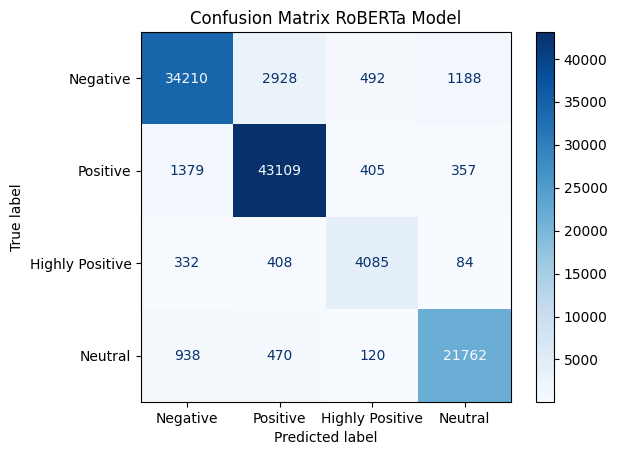

In [ ]:
disp = ConfusionMatrixDisplay(cm,display_labels=["Negative","Positive","Highly Positive","Neutral"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix RoBERTa Model")
plt.show()

**Classification Report**

In [ ]:
from sklearn.metrics import classification_report
report = classification_report(labels, predicted_labels, labels=[0,1,2,3], target_names=["Negative","Positive","Highly Positive","Neutral"])
print(report)

                 precision    recall  f1-score   support

       Negative       0.93      0.88      0.90     38818
       Positive       0.92      0.95      0.94     45250
Highly Positive       0.80      0.83      0.82      4909
        Neutral       0.93      0.93      0.93     23290

       accuracy                           0.92    112267
      macro avg       0.89      0.90      0.90    112267
   weighted avg       0.92      0.92      0.92    112267



**ROC Curve**

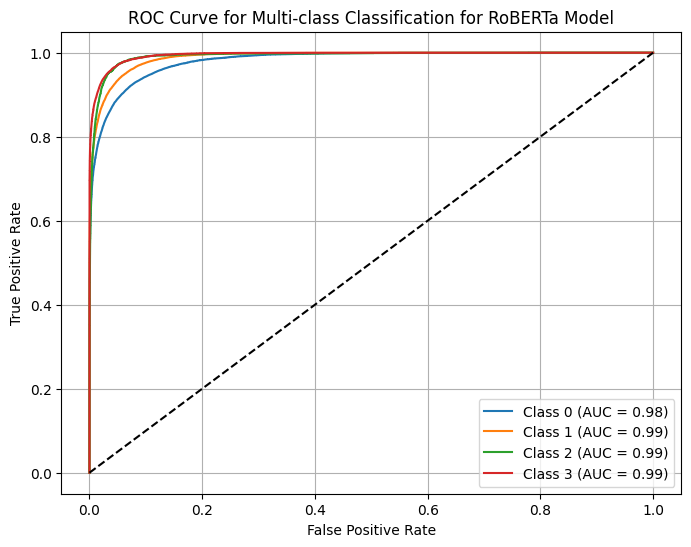

<Figure size 640x480 with 0 Axes>

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

predicted_probs = predictions

true_labels_binarized = label_binarize(labels, classes=[0, 1, 2, 3])

plt.figure(figsize=(8, 6))

for i in range(true_labels_binarized.shape[1]):
    fpr, tpr, thresholds = roc_curve(true_labels_binarized[:, i], predicted_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='black', linestyle='--')


plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Multi-class Classification for RoBERTa Model')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

plt.savefig('roc_curve.png', dpi=300)
plt.show()

**Precision Recall Curve**

Shape of true_labels_binarized: (112267, 4)
Shape of predicted_probs: (112267, 4)


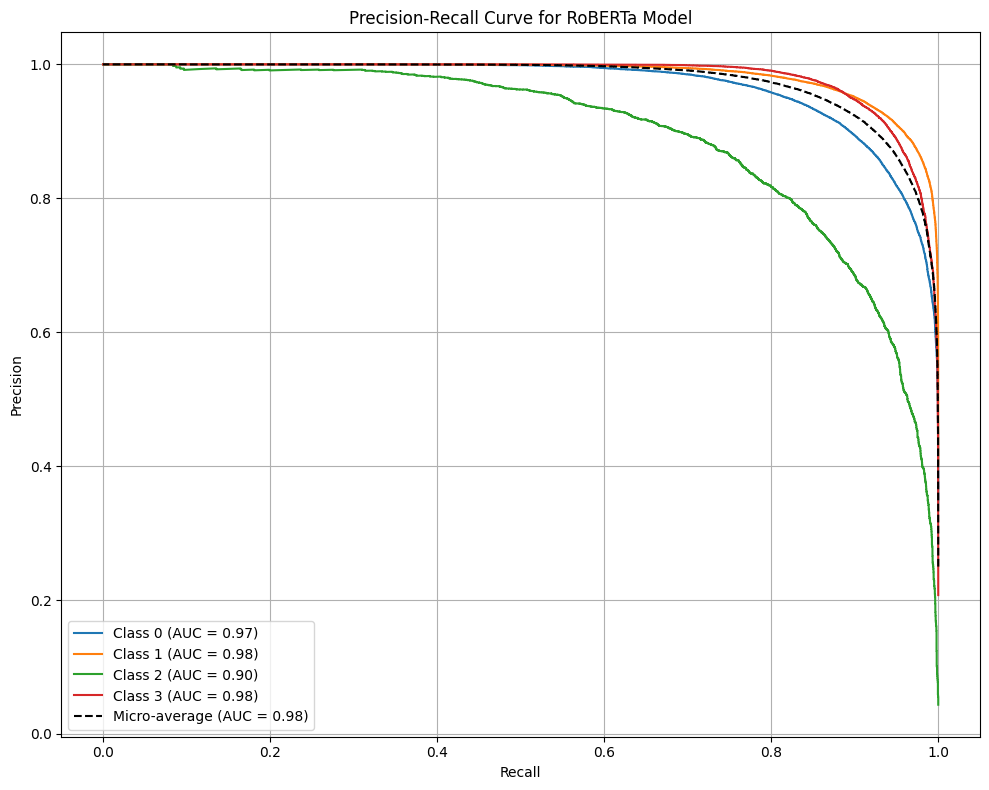

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, auc

# assert len(labels) == len(predicted_probs), "Mismatch in number of samples"
predicted_probs = predicted_probs[:, :4]
true_labels_binarized = label_binarize(labels, classes=[0, 1, 2, 3])

print(f"Shape of true_labels_binarized: {true_labels_binarized.shape}")
print(f"Shape of predicted_probs: {predicted_probs.shape}")

precision, recall, pr_auc = {}, {}, {}
for i in range(true_labels_binarized.shape[1]):
    precision[i], recall[i], _ = precision_recall_curve(true_labels_binarized[:, i], predicted_probs[:, i])
    pr_auc[i] = auc(recall[i], precision[i])

precision_micro, recall_micro, _ = precision_recall_curve(true_labels_binarized.ravel(), predicted_probs.ravel())
pr_auc_micro = auc(recall_micro, precision_micro)

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))

for i in range(true_labels_binarized.shape[1]):
    plt.plot(recall[i], precision[i], label=f'Class {i} (AUC = {pr_auc[i]:.2f})')

plt.plot(recall_micro, precision_micro, label=f'Micro-average (AUC = {pr_auc_micro:.2f})', linestyle='--', color='black')

plt.title('Precision-Recall Curve for RoBERTa Model')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc="lower left")
plt.grid(True)
plt.tight_layout()

plt.show()

**Training And Testing Loss Curve**

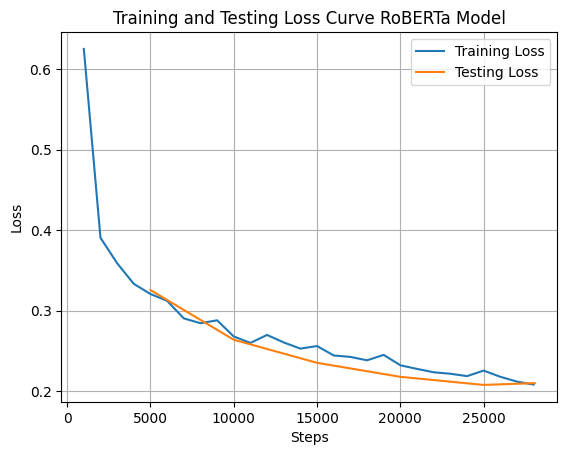

In [ ]:
import matplotlib.pyplot as plt

trainer_state = trainer.state

train_loss = [log['loss'] for log in trainer_state.log_history if 'loss' in log]
train_steps = [log['step'] for log in trainer_state.log_history if 'loss' in log]

eval_loss = [log['eval_loss'] for log in trainer_state.log_history if 'eval_loss' in log]
eval_steps = [log['step'] for log in trainer_state.log_history if 'eval_loss' in log]

plt.plot(train_steps, train_loss, label="Training Loss")

plt.plot(eval_steps, eval_loss, label="Testing Loss")

plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training and Testing Loss Curve RoBERTa Model")
plt.legend()
plt.grid()
plt.show()

**Training and Evaluation Accuracy Curve**

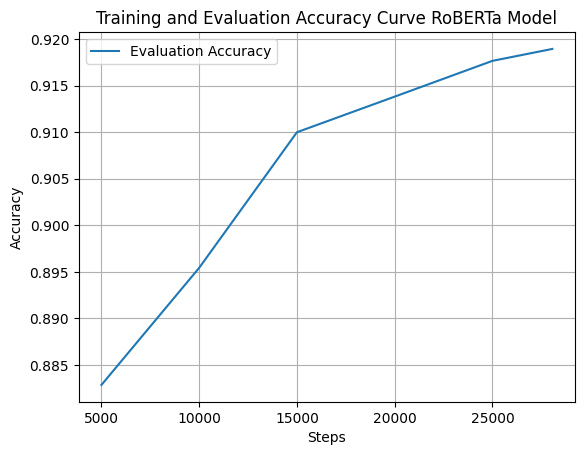

In [ ]:
import matplotlib.pyplot as plt
trainer_state = trainer.state
train_accuracy = [log['train_accuracy'] for log in trainer_state.log_history if 'train_accuracy' in log]
train_steps = [log['step'] for log in trainer_state.log_history if 'train_accuracy' in log]

eval_accuracy = [log['eval_accuracy'] for log in trainer_state.log_history if 'eval_accuracy' in log]
eval_steps = [log['step'] for log in trainer_state.log_history if 'eval_accuracy' in log]

if train_accuracy:
    plt.plot(train_steps,train_accuracy, label="Training Accuracy")

plt.plot(eval_steps, eval_accuracy, label="Evaluation Accuracy")

plt.xlabel("Steps")
plt.ylabel("Accuracy")
plt.title("Training and Evaluation Accuracy Curve RoBERTa Model")
plt.legend()
plt.grid()
plt.show()

**BERT Model**

In [ ]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 449066
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 112267
    })
})

In [ ]:
test_dataset=dataset['test']
test_dataset

Dataset({
    features: ['text', 'label'],
    num_rows: 112267
})

In [ ]:
from transformers import BertTokenizer, BertModel
from transformers import BertForSequenceClassification

bert="google-bert/bert-base-uncased"
bert_tokenizer = BertTokenizer.from_pretrained(bert)
bert_model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=4)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
def bert_preprocess_text(text):
    bert_tokenized_output = bert_tokenizer(text['text'], padding="max_length", truncation=True,return_tensors="pt",max_length=512)
    bert_tokenized_output['label'] = text['label']
    return bert_tokenized_output

bert_tokenized_datasets = dataset.map(bert_preprocess_text,batched=True,remove_columns=['text'])

Map:   0%|          | 0/449066 [00:00<?, ? examples/s]

Map:   0%|          | 0/112267 [00:00<?, ? examples/s]

In [ ]:
bert_tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 449066
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 112267
    })
})

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(p):
    preds = p.predictions.argmax(axis=-1)
    labels = p.label_ids
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted', zero_division=1)
    accuracy = accuracy_score(labels, preds)
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

In [ ]:
training_args = TrainingArguments(
    output_dir='./BERT-Tuned',
    evaluation_strategy="steps",
    save_strategy="steps",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=1,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=1000,
    save_steps=10000,
    eval_steps=5000,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    report_to='none',
    warmup_steps=1500,
    remove_unused_columns=False,
)

/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [ ]:
bert_trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=bert_tokenized_datasets['train'],
    eval_dataset=bert_tokenized_datasets['test'],
    tokenizer=bert_tokenizer,
    compute_metrics=compute_metrics,
)
bert_trainer.train()

<ipython-input-174-ad898e7920bf>:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  bert_trainer = Trainer(


Step,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
5000,0.307300,0.302817,0.881809,0.886653,0.881809,0.879001
10000,0.258800,0.243855,0.905288,0.907873,0.905288,0.905736
15000,0.240000,0.232013,0.911630,0.913371,0.911630,0.912100
20000,0.221200,0.208280,0.917892,0.917876,0.917892,0.917878
25000,0.210800,0.193447,0.922444,0.922315,0.922444,0.922289


Could not locate the best model at ./BERT-Tuned/checkpoint-25000/pytorch_model.bin, if you are running a distributed training on multiple nodes, you should activate `--save_on_each_node`.


TrainOutput(global_step=28067, training_loss=0.2664669546338734, metrics={'train_runtime': 12898.0005, 'train_samples_per_second': 34.817, 'train_steps_per_second': 2.176, 'total_flos': 1.1815635090459034e+17, 'train_loss': 0.2664669546338734, 'epoch': 1.0})

In [ ]:
bert_results=bert_trainer.evaluate()
bert_results

{'eval_loss': 0.1950233429670334,
 'eval_accuracy': 0.923423624039121,
 'eval_precision': 0.9234291934423041,
 'eval_recall': 0.923423624039121,
 'eval_f1': 0.9233653674979663,
 'eval_runtime': 775.7071,
 'eval_samples_per_second': 144.729,
 'eval_steps_per_second': 9.046,
 'epoch': 1.0}

In [ ]:
bert_test_dataset=bert_tokenized_datasets['test']
bert_test_dataset

Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 112267
})

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

predictions, labels, _ = bert_trainer.predict(bert_test_dataset)

predicted_labels = np.argmax(predictions, axis=1)
predicted_labels

array([3, 2, 1, ..., 3, 1, 1])

**Confusion Matrix**

In [ ]:
cm=confusion_matrix(labels, predicted_labels)
cm

array([[35046,  2403,   369,  1000],
       [ 1717, 42865,   378,   290],
       [  389,   348,  4099,    73],
       [ 1035,   480,   115, 21660]])

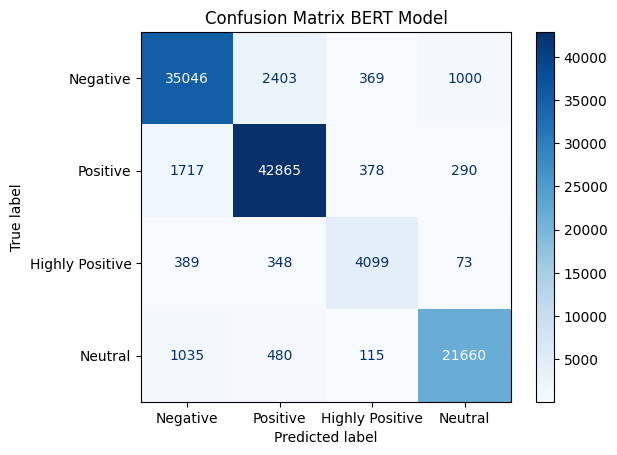

In [ ]:
disp = ConfusionMatrixDisplay(cm,display_labels=["Negative","Positive","Highly Positive","Neutral"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix BERT Model")
plt.show()

**Classification Report**

In [ ]:
from sklearn.metrics import classification_report
report = classification_report(labels, predicted_labels, labels=[0,1,2,3], target_names=["Negative","Positive","Highly Positive","Neutral"])
print(report)

                 precision    recall  f1-score   support

       Negative       0.92      0.90      0.91     38818
       Positive       0.93      0.95      0.94     45250
Highly Positive       0.83      0.83      0.83      4909
        Neutral       0.94      0.93      0.94     23290

       accuracy                           0.92    112267
      macro avg       0.90      0.90      0.90    112267
   weighted avg       0.92      0.92      0.92    112267



**Roc Curve**

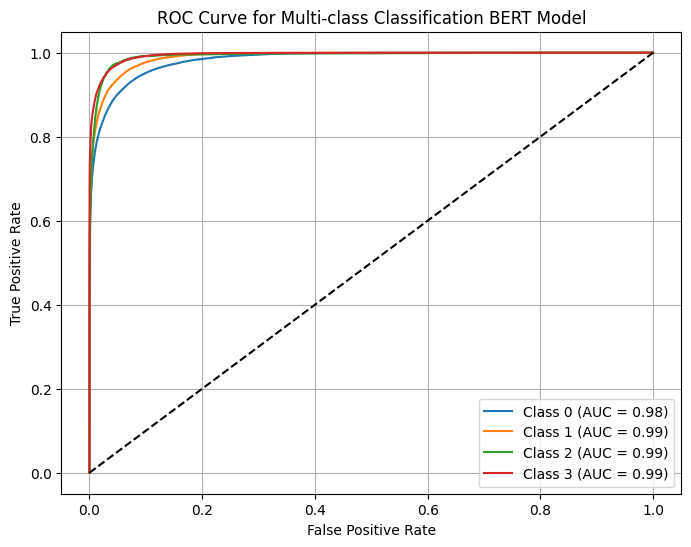

<Figure size 640x480 with 0 Axes>

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

predicted_probs = predictions

true_labels_binarized = label_binarize(labels, classes=[0, 1, 2, 3])

plt.figure(figsize=(8, 6))

for i in range(true_labels_binarized.shape[1]):
    fpr, tpr, thresholds = roc_curve(true_labels_binarized[:, i], predicted_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='black', linestyle='--')


plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Multi-class Classification BERT Model')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

plt.savefig('roc_curve.png', dpi=300)
plt.show()

**Precision Recall Curve**

Shape of true_labels_binarized: (112267, 4)
Shape of predicted_probs: (112267, 4)


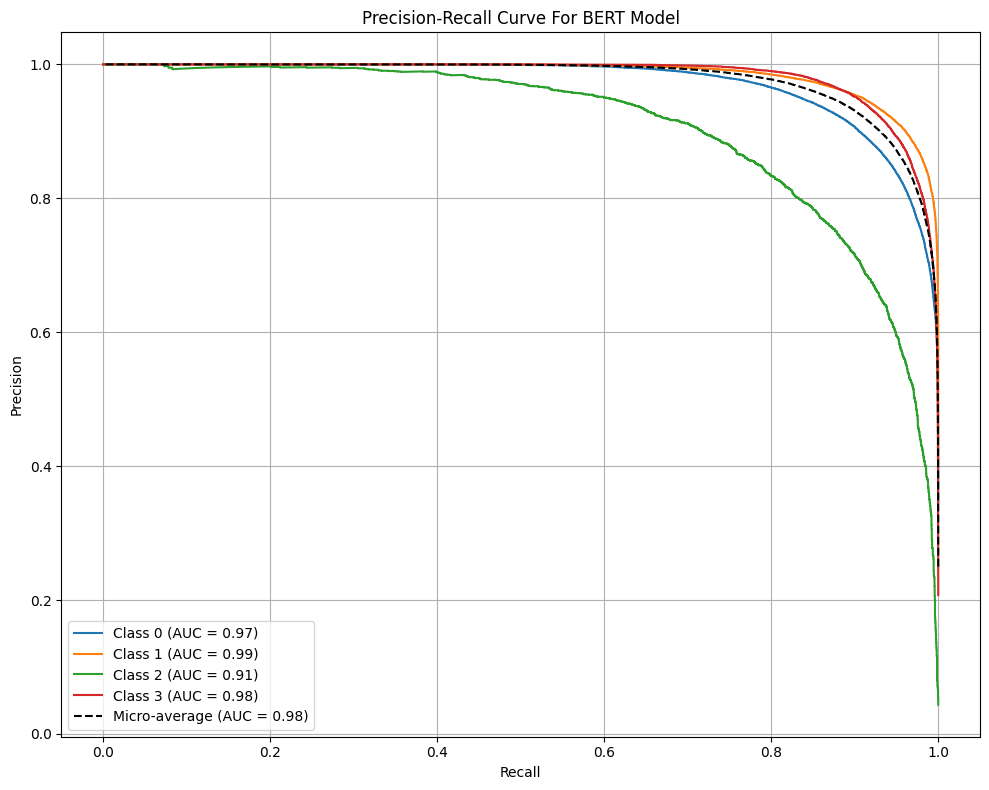

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, auc

# assert len(labels) == len(predicted_probs), "Mismatch in number of samples"
predicted_probs = predicted_probs[:, :4]
true_labels_binarized = label_binarize(labels, classes=[0, 1, 2, 3])

print(f"Shape of true_labels_binarized: {true_labels_binarized.shape}")
print(f"Shape of predicted_probs: {predicted_probs.shape}")

precision, recall, pr_auc = {}, {}, {}
for i in range(true_labels_binarized.shape[1]):
    precision[i], recall[i], _ = precision_recall_curve(true_labels_binarized[:, i], predicted_probs[:, i])
    pr_auc[i] = auc(recall[i], precision[i])

precision_micro, recall_micro, _ = precision_recall_curve(true_labels_binarized.ravel(), predicted_probs.ravel())
pr_auc_micro = auc(recall_micro, precision_micro)

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))

for i in range(true_labels_binarized.shape[1]):
    plt.plot(recall[i], precision[i], label=f'Class {i} (AUC = {pr_auc[i]:.2f})')

plt.plot(recall_micro, precision_micro, label=f'Micro-average (AUC = {pr_auc_micro:.2f})', linestyle='--', color='black')

plt.title('Precision-Recall Curve For BERT Model')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc="lower left")
plt.grid(True)
plt.tight_layout()

plt.show()

**Training And Testing Loss Curve**

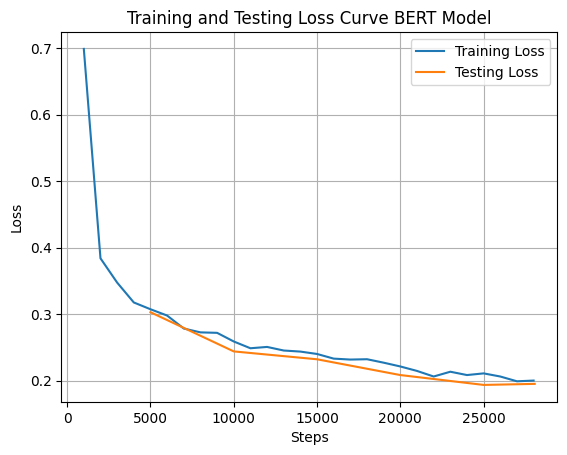

In [ ]:
import matplotlib.pyplot as plt

trainer_state = bert_trainer.state

train_loss = [log['loss'] for log in trainer_state.log_history if 'loss' in log]
train_steps = [log['step'] for log in trainer_state.log_history if 'loss' in log]

eval_loss = [log['eval_loss'] for log in trainer_state.log_history if 'eval_loss' in log]
eval_steps = [log['step'] for log in trainer_state.log_history if 'eval_loss' in log]

plt.plot(train_steps, train_loss, label="Training Loss")

plt.plot(eval_steps, eval_loss, label="Testing Loss")

plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training and Testing Loss Curve BERT Model")
plt.legend()
plt.grid()
plt.show()

**Training And Evaluation Accuracy Curve**

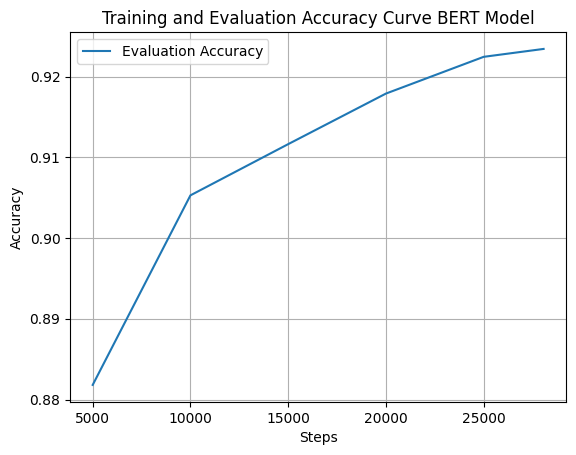

In [ ]:
import matplotlib.pyplot as plt
trainer_state = bert_trainer.state
train_accuracy = [log['train_accuracy'] for log in trainer_state.log_history if 'train_accuracy' in log]
train_steps = [log['step'] for log in trainer_state.log_history if 'train_accuracy' in log]

eval_accuracy = [log['eval_accuracy'] for log in trainer_state.log_history if 'eval_accuracy' in log]
eval_steps = [log['step'] for log in trainer_state.log_history if 'eval_accuracy' in log]

if train_accuracy:
    plt.plot(train_steps,train_accuracy, label="Training Accuracy")

plt.plot(eval_steps, eval_accuracy, label="Evaluation Accuracy")

plt.xlabel("Steps")
plt.ylabel("Accuracy")
plt.title("Training and Evaluation Accuracy Curve BERT Model")
plt.legend()
plt.grid()
plt.show()

**Sentence Transformers Model**

In [ ]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 449066
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 112267
    })
})

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

minilm = "sentence-transformers/all-MiniLM-L6-v2"
tokenizer = AutoTokenizer.from_pretrained(minilm)
model = AutoModelForSequenceClassification.from_pretrained(minilm, num_labels=4)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sentence-transformers/all-MiniLM-L6-v2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
def preprocess_text(text):
    tokenized_output = tokenizer(text['text'], padding="max_length", truncation=True,return_tensors="pt",max_length=512)
    tokenized_output['label'] = text['label']
    return tokenized_output

tokenized_datasets = dataset.map(preprocess_text,batched=True,remove_columns=['text'])

Map:   0%|          | 0/449066 [00:00<?, ? examples/s]

Map:   0%|          | 0/112267 [00:00<?, ? examples/s]

In [ ]:
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 449066
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 112267
    })
})

In [ ]:
test_dataset=tokenized_datasets['test']
test_dataset

Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 112267
})

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(p):
    preds = p.predictions.argmax(axis=-1)
    labels = p.label_ids
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted', zero_division=1)
    accuracy = accuracy_score(labels, preds)
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

In [ ]:
training_args = TrainingArguments(
    output_dir='./Sentence-Transformers-Tuned',
    evaluation_strategy="steps",
    save_strategy="steps",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=1,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=1000,
    save_steps=10000,
    eval_steps=5000,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    report_to='none',
    warmup_steps=1600,
    remove_unused_columns=False,
)

/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets['train'],
    eval_dataset=tokenized_datasets['test'],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)
trainer.train()

<ipython-input-197-ba1ae3f6a226>:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
5000,0.281100,0.256765,0.902340,0.904434,0.902340,0.900355
10000,0.240600,0.215468,0.913269,0.921600,0.913269,0.915973
15000,0.228500,0.179616,0.928813,0.928983,0.928813,0.928894
20000,0.204400,0.171322,0.933026,0.933387,0.933026,0.933185
25000,0.205600,0.154912,0.938165,0.937895,0.938165,0.937993


Could not locate the best model at ./Sentence-Transformers-Tuned/checkpoint-25000/pytorch_model.bin, if you are running a distributed training on multiple nodes, you should activate `--save_on_each_node`.


TrainOutput(global_step=28067, training_loss=0.25610313673084306, metrics={'train_runtime': 3275.3486, 'train_samples_per_second': 137.105, 'train_steps_per_second': 8.569, 'total_flos': 1.4894699721252864e+16, 'train_loss': 0.25610313673084306, 'epoch': 1.0})

In [ ]:
results=trainer.evaluate()
results

{'eval_loss': 0.1567184180021286,
 'eval_accuracy': 0.9378713246100813,
 'eval_precision': 0.9380814442002623,
 'eval_recall': 0.9378713246100813,
 'eval_f1': 0.9377669138202913,
 'eval_runtime': 223.7405,
 'eval_samples_per_second': 501.773,
 'eval_steps_per_second': 31.362,
 'epoch': 1.0}

In [ ]:
test_dataset=tokenized_datasets['test']
test_dataset

Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 112267
})

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

predictions, labels, _ = trainer.predict(test_dataset)

predicted_labels = np.argmax(predictions, axis=1)
predicted_labels

array([3, 2, 1, ..., 3, 1, 1])

**Confusion Matrix**

In [ ]:
cm=confusion_matrix(labels, predicted_labels)
cm

array([[35595,  1977,   347,   899],
       [  945, 43470,   591,   244],
       [  242,   749,  3873,    45],
       [  519,   341,    76, 22354]])

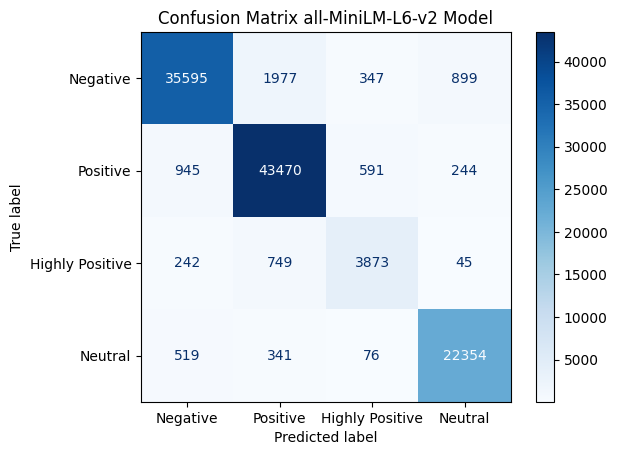

In [ ]:
disp = ConfusionMatrixDisplay(cm,display_labels=["Negative","Positive","Highly Positive","Neutral"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix all-MiniLM-L6-v2 Model")
plt.show()

**Classification Report**

In [ ]:
from sklearn.metrics import classification_report
report = classification_report(labels, predicted_labels, labels=[0,1,2,3], target_names=["Negative","Positive","Highly Positive","Neutral"])
print(report)

                 precision    recall  f1-score   support

       Negative       0.95      0.92      0.94     38818
       Positive       0.93      0.96      0.95     45250
Highly Positive       0.79      0.79      0.79      4909
        Neutral       0.95      0.96      0.95     23290

       accuracy                           0.94    112267
      macro avg       0.91      0.91      0.91    112267
   weighted avg       0.94      0.94      0.94    112267



**ROC Curve**

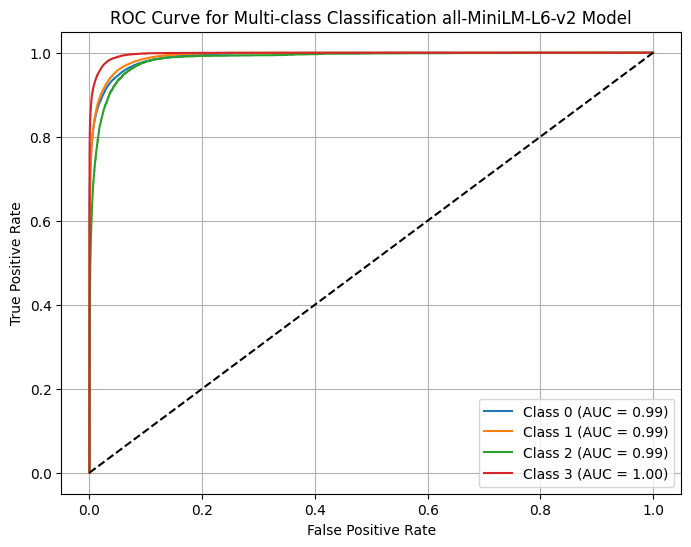

<Figure size 640x480 with 0 Axes>

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

predicted_probs = predictions

true_labels_binarized = label_binarize(labels, classes=[0, 1, 2, 3])

plt.figure(figsize=(8, 6))

for i in range(true_labels_binarized.shape[1]):
    fpr, tpr, thresholds = roc_curve(true_labels_binarized[:, i], predicted_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='black', linestyle='--')


plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Multi-class Classification all-MiniLM-L6-v2 Model')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

plt.savefig('roc_curve.png', dpi=300)
plt.show()

**Precision Recall Curve**

Shape of true_labels_binarized: (112267, 4)
Shape of predicted_probs: (112267, 4)


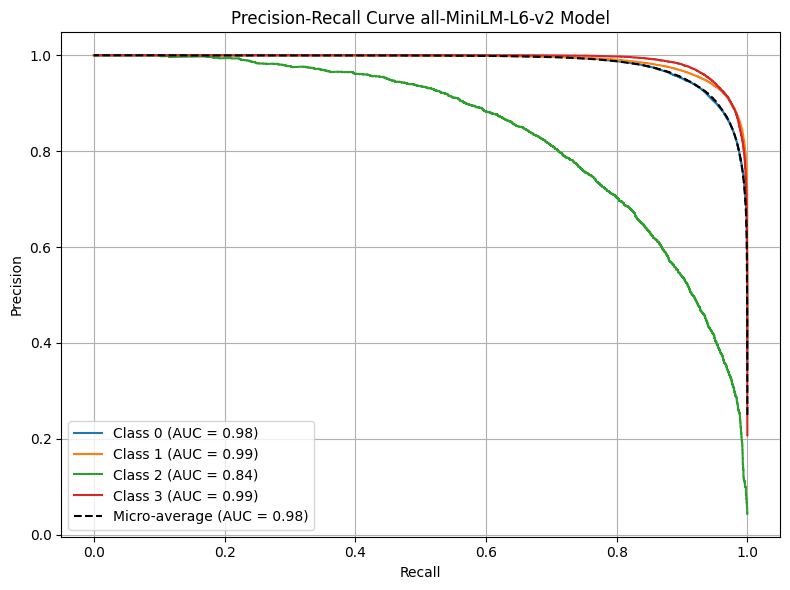

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, auc

# assert len(labels) == len(predicted_probs), "Mismatch in number of samples"
predicted_probs = predicted_probs[:, :4]
true_labels_binarized = label_binarize(labels, classes=[0, 1, 2, 3])

print(f"Shape of true_labels_binarized: {true_labels_binarized.shape}")
print(f"Shape of predicted_probs: {predicted_probs.shape}")

precision, recall, pr_auc = {}, {}, {}
for i in range(true_labels_binarized.shape[1]):
    precision[i], recall[i], _ = precision_recall_curve(true_labels_binarized[:, i], predicted_probs[:, i])
    pr_auc[i] = auc(recall[i], precision[i])

precision_micro, recall_micro, _ = precision_recall_curve(true_labels_binarized.ravel(), predicted_probs.ravel())
pr_auc_micro = auc(recall_micro, precision_micro)

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))

for i in range(true_labels_binarized.shape[1]):
    plt.plot(recall[i], precision[i], label=f'Class {i} (AUC = {pr_auc[i]:.2f})')

plt.plot(recall_micro, precision_micro, label=f'Micro-average (AUC = {pr_auc_micro:.2f})', linestyle='--', color='black')

plt.title('Precision-Recall Curve all-MiniLM-L6-v2 Model')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc="lower left")
plt.grid(True)
plt.tight_layout()

plt.show()

**Loss Curve**

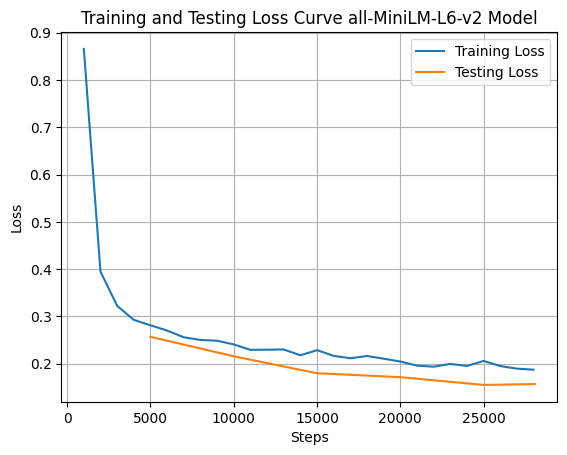

In [ ]:
import matplotlib.pyplot as plt

trainer_state = trainer.state

train_loss = [log['loss'] for log in trainer_state.log_history if 'loss' in log]
train_steps = [log['step'] for log in trainer_state.log_history if 'loss' in log]

eval_loss = [log['eval_loss'] for log in trainer_state.log_history if 'eval_loss' in log]
eval_steps = [log['step'] for log in trainer_state.log_history if 'eval_loss' in log]

plt.plot(train_steps, train_loss, label="Training Loss")

plt.plot(eval_steps, eval_loss, label="Testing Loss")

plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training and Testing Loss Curve all-MiniLM-L6-v2 Model")
plt.legend()
plt.grid()
plt.show()

**Accuracy Curve**

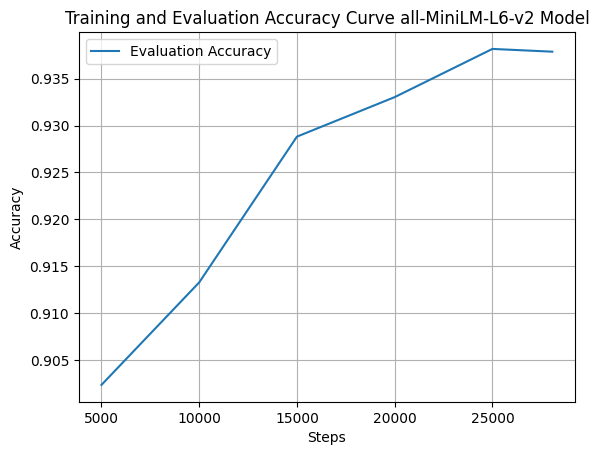

In [ ]:
import matplotlib.pyplot as plt
trainer_state = trainer.state
train_accuracy = [log['train_accuracy'] for log in trainer_state.log_history if 'train_accuracy' in log]
train_steps = [log['step'] for log in trainer_state.log_history if 'train_accuracy' in log]

eval_accuracy = [log['eval_accuracy'] for log in trainer_state.log_history if 'eval_accuracy' in log]
eval_steps = [log['step'] for log in trainer_state.log_history if 'eval_accuracy' in log]

if train_accuracy:
    plt.plot(train_steps,train_accuracy, label="Training Accuracy")

plt.plot(eval_steps, eval_accuracy, label="Evaluation Accuracy")

plt.xlabel("Steps")
plt.ylabel("Accuracy")
plt.title("Training and Evaluation Accuracy Curve all-MiniLM-L6-v2 Model")
plt.legend()
plt.grid()
plt.show()